In [1]:
import numpy as np
import pandas as pd
import random

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

from sklearn.preprocessing import LabelEncoder
from sklearn import ensemble
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, auc, roc_curve

from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import os
import shutil
import pathlib
from tqdm import tqdm

from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier
import joblib
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler



import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning. 

### Baseline
Use the distribution of the raw data in the training set to randomly guess an outcome. 

In [230]:
### baseline guessing based on the distribution of the raw training dataset
y_train_raw = pd.read_parquet("../data/model_raw/Y_train.parquet")
y_train_raw['dep_bin'] = np.where(y_train_raw['depression_severity'] > 0, 1, 0)
y_test = pd.read_parquet("../data/model_raw/Y_test.parquet")['depression_severity']
y_test = np.array(np.where(y_test > 0, 1, 0)) # np array of binary labels

counts = pd.DataFrame(y_train_raw['dep_bin'].value_counts()).reset_index()

guess_0 = counts[counts['dep_bin'] == 0]['count']/counts['count'].sum()
guess_1 = counts[counts['dep_bin'] == 1]['count'] / counts['count'].sum()

ones = np.ones(round(len(y_test) * guess_1).astype(int))
zeros = np.zeros(round(len(y_test) * guess_0).astype(int))

# concatenate 1 and 0 guesses
out = np.concatenate((ones, zeros))
random_df = pd.DataFrame(out, columns=['pred'])

# shuffle 1 and 0 guesses randomly
np.random.seed(12345)
indices = random_df.index.tolist()
shuffled_indices = np.random.permutation(indices)
random_df = random_df.reindex(shuffled_indices).reset_index(drop=True)

In [248]:
df_counts = pd.DataFrame(y_train_raw['dep_bin'].value_counts()).reset_index()
df_counts.columns = ['pred', 'count']

# compute percentages
df_counts['percent'] = df_counts['count'] / df_counts['count'].sum() * 100

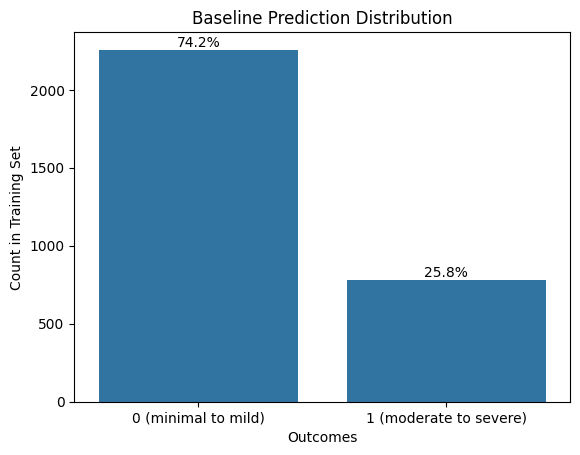

In [252]:
ax = sns.barplot(x='pred', y='count', data=df_counts)

# add percentage labels on bars
for i, row in df_counts.iterrows():
    ax.text(i, row['count'], f"{row['percent']:.1f}%", 
            ha='center', va='bottom')

# Set custom tick labels
ax.set_xticklabels([
    "0 (minimal to mild)",
    "1 (moderate to severe)"
])
plt.ylabel("Count in Training Set")
plt.xlabel("Outcomes")
plt.title("Baseline Prediction Distribution")

plt.show()

In [231]:
classification_report(y_test, np.array(random_df['pred']), output_dict=True)

{'0': {'precision': 0.7689243027888446,
  'recall': 0.7461340206185567,
  'f1-score': 0.7573577501635056,
  'support': 776.0},
 '1': {'precision': 0.24521072796934865,
  'recall': 0.2689075630252101,
  'f1-score': 0.2565130260521042,
  'support': 238.0},
 'accuracy': 0.6341222879684418,
 'macro avg': {'precision': 0.5070675153790967,
  'recall': 0.5075207918218834,
  'f1-score': 0.5069353881078049,
  'support': 1014.0},
 'weighted avg': {'precision': 0.6460013927227302,
  'recall': 0.6341222879684418,
  'f1-score': 0.6398024796127033,
  'support': 1014.0}}

In [232]:
# auc
fpr, tpr, _ = roc_curve(y_test, np.array(random_df['pred']))
roc_auc = auc(fpr, tpr)
roc_auc

0.5075207918218834

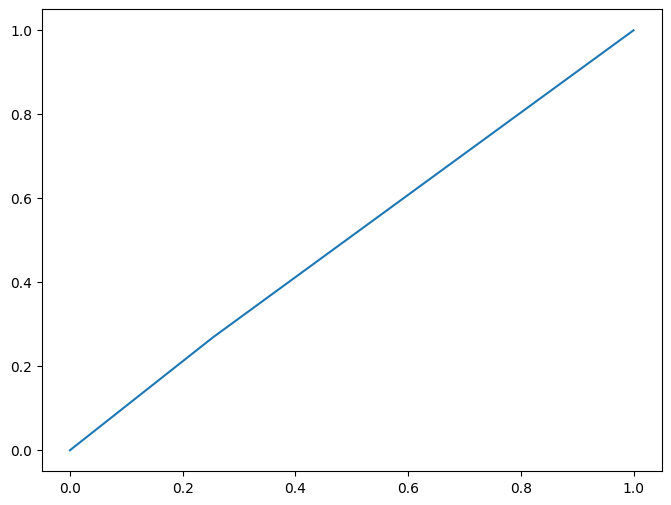

In [233]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Baseline Distribution-Based Classifiier (AUC = {roc_auc:.3f})")

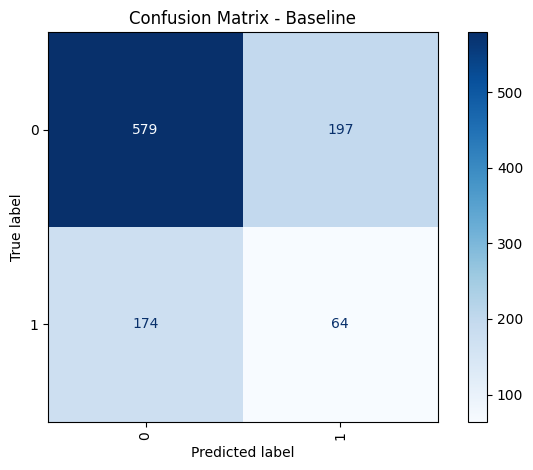

In [229]:
# confusion matrix on baseline set
cm = confusion_matrix(y_test, np.array(random_df['pred']))
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Confusion Matrix - Baseline")
plt.tight_layout()
plt.show()

### Random Forest models

In [ ]:
# load train data
X_train_raw = pd.read_parquet("../data/model_raw/X_train.parquet")
y_train_raw = pd.read_parquet("../data/model_raw/Y_train.parquet")
y_train_raw = np.where(y_train_raw['depression_severity'] > 0, 1, 0) # create binary labels

# upsample train data - do what you need to do
ros = RandomOverSampler(sampling_strategy='not majority', random_state=7)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train_raw, y_train_raw)

# convert X and Y to np array
X_train = np.array(X_train_balanced)
y_train = np.array(y_train_balanced)

# load validation data
X_val = pd.read_parquet("../data/model_raw/X_val.parquet")
y_val = pd.read_parquet("../data/model_raw/Y_val.parquet")['depression_severity']
X_val = np.array(X_val)
y_val = np.array(np.where(y_val > 0, 1, 0)) # np array of binary labels

# load test data
X_test = pd.read_parquet("../data/model_raw/X_test.parquet")
y_test = pd.read_parquet("../data/model_raw/Y_test.parquet")['depression_severity']
X_test = np.array(X_test)
y_test = np.array(np.where(y_test > 0, 1, 0)) # np array of binary labels

In [118]:
# post oversampled data to folder
pd.DataFrame(X_train_balanced).to_parquet("../data/model_upsampled/X_train_balanced.parquet")
pd.DataFrame(y_train_balanced).to_parquet("../data/model_upsampled/Y_train_balanced.parquet")

In [179]:
X_train.shape

(4514, 146)

Train accuracy: 0.7864
Validation accuracy: 0.6696


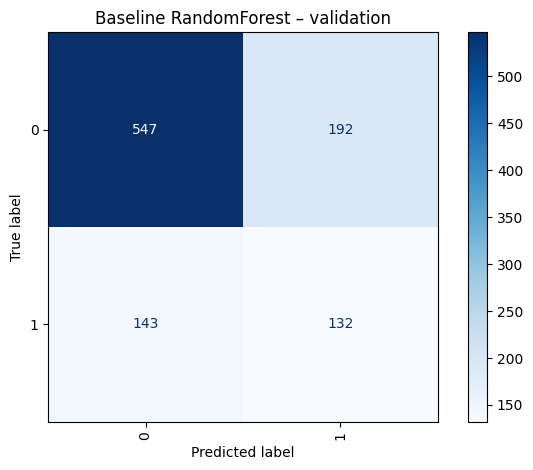

In [121]:
# baseline simple classifier
rf_clf = RandomForestClassifier(
    n_estimators=2,
    n_jobs=1,
    random_state=7,
    max_depth=8
)

# train
rf_clf.fit(X_train, y_train)

# predictions
y_train_pred = rf_clf.predict(X_train)
y_val_pred   = rf_clf.predict(X_val)

# accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy   = accuracy_score(y_val, y_val_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

# confusion matrix using validation set
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Baseline RandomForest – validation")
plt.tight_layout()
plt.show()

### Make it better

In [163]:
def performance_metrics(mod, X_train, y_train,  X_val, y_val, verbose  = True):
    # predictions
    y_train_pred = mod.predict(X_train)
    y_val_pred   = mod.predict(X_val)

    # accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    val_accuracy   = accuracy_score(y_val, y_val_pred)

    if verbose:
        print(f"Train accuracy: {train_accuracy:.4f}")
        print(f"Validation accuracy: {val_accuracy:.4f}")
        print(f'Classification report: \n {classification_report(y_val, y_val_pred)}')
    return classification_report(y_val, y_val_pred, output_dict=True)

def parse_metrics(metrics):
    return {
        'n_estimators': metrics['n_estimators'],
        
        # overall
        'accuracy': metrics['accuracy'],
        
        # class 0
        'precision_0': metrics['0']['precision'],
        'recall_0': metrics['0']['recall'],
        'f1_0': metrics['0']['f1-score'],
        
        # class 1
        'precision_1': metrics['1']['precision'],
        'recall_1': metrics['1']['recall'],
        'f1_1': metrics['1']['f1-score'],
        
        # averages
        'macro_f1': metrics['macro avg']['f1-score'],
        'weighted_f1': metrics['weighted avg']['f1-score']
    }


In [ ]:
# pca = PCA(n_components=80, random_state=7)

# pca.fit(X_train)

# X_train_pca = pca.transform(X_train)
# X_val_pca   = pca.transform(X_val)

In [ ]:
rf  = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1, 
    random_state=7, 
    max_depth=12, 
    max_features='log2', 
    min_samples_leaf = 15, 
    min_samples_split = 15)

rf.fit(X_train, y_train)

# save model
joblib.dump(rf, "nhanes_rf_1.pkl")

# load model from file
gb2 = joblib.load("nhanes_rf_1.pkl")

performance_metrics(gb2, X_train, y_train, X_val, y_val)


Train accuracy: 0.8899
Validation accuracy: 0.7702
Classification report: 
               precision    recall  f1-score   support

           0       0.84      0.84      0.84       739
           1       0.57      0.59      0.58       275

    accuracy                           0.77      1014
   macro avg       0.71      0.71      0.71      1014
weighted avg       0.77      0.77      0.77      1014



In [153]:
results = []

n_estimators_list = [50, 100, 200, 300, 500, 1000, 1500, 2000]

for n in n_estimators_list:
    
    rf = RandomForestClassifier(
        n_estimators=n,
        n_jobs=-1,
        random_state=7,
        max_depth=12,
        max_features='log2',
        min_samples_leaf=15,
        min_samples_split=15
    )
    
    rf.fit(X_train, y_train)
    
    # save model
    filename = f"nhanes_rf_{n}.pkl"
    joblib.dump(rf, filename)
    
    # evaluate
    metrics = performance_metrics(rf, X_train, y_train, X_val, y_val, print=False)
    
    # assume performance_metrics returns a dict
    metrics['n_estimators'] = n

    parsed = parse_metrics(metrics)
    results.append(parsed)

# convert to dataframe
results_df = pd.DataFrame(results)

# sort by your key metric (example: recall)
results_df

,n_estimators,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,macro_f1,weighted_f1
0,50,0.764300,0.839674,0.836265,0.837966,0.564748,0.570909,0.567812,0.702889,0.764699
1,100,0.770217,0.844687,0.838972,0.841819,0.575000,0.585455,0.580180,0.711000,0.770862
2,200,0.773176,0.846259,0.841678,0.843962,0.580645,0.589091,0.584838,0.714400,0.773687
3,300,0.773176,0.842530,0.847091,0.844804,0.583026,0.574545,0.578755,0.711779,0.772651
4,500,0.773176,0.844384,0.844384,0.844384,0.581818,0.581818,0.581818,0.713101,0.773176
5,1000,0.768245,0.842391,0.838972,0.840678,0.571942,0.578182,0.575045,0.707862,0.768638
6,1500,0.769231,0.843537,0.838972,0.841248,0.573477,0.581818,0.577617,0.709433,0.769751
7,2000,0.770217,0.843750,0.840325,0.842034,0.575540,0.581818,0.578662,0.710348,0.770607


In [ ]:
results = []

depths = [5, 8, 10, 12, 15, 18, 20]

for n in depths:
    
    rf = RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=7,
        max_depth=n,
        max_features='log2',
        min_samples_leaf=15,
        min_samples_split=15
    )
    
    rf.fit(X_train, y_train)
    
    # save model
    filename = f"nhanes_rf_{n}_depth.pkl"
    joblib.dump(rf, filename)
    
    # evaluate
    metrics = performance_metrics(rf, X_train, y_train, X_val, y_val, print=False)
    
    # assume performance_metrics returns a dict
    metrics['n_estimators'] = n

    parsed = parse_metrics(metrics)
    results.append(parsed)

# convert to dataframe
results_df = pd.DataFrame(results)

results_df

,n_estimators,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,macro_f1,weighted_f1
0,5,0.745562,0.857355,0.780785,0.817280,0.524927,0.650909,0.581169,0.699225,0.753246
1,8,0.765286,0.850350,0.822733,0.836314,0.561873,0.610909,0.585366,0.710840,0.768256
2,10,0.762327,0.840164,0.832206,0.836166,0.560284,0.574545,0.567325,0.701745,0.763255
3,12,0.773176,0.846259,0.841678,0.843962,0.580645,0.589091,0.584838,0.714400,0.773687
4,15,0.763314,0.844138,0.828146,0.836066,0.560554,0.589091,0.574468,0.705267,0.765120
5,18,0.761341,0.838095,0.833559,0.835821,0.559140,0.567273,0.563177,0.699499,0.761879
6,20,0.770217,0.844687,0.838972,0.841819,0.575000,0.585455,0.580180,0.711000,0.770862


In [ ]:
results = []

min_samples_leaf = [5, 10, 15, 20]

for n in min_samples_leaf:
    
    rf = RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=7,
        max_depth=5,
        max_features='log2',
        min_samples_leaf=n,
        min_samples_split=15
    )
    
    rf.fit(X_train, y_train)
    
    # save model
    filename = f"nhanes_rf_{n}_leafs.pkl"
    joblib.dump(rf, filename)
    
    # evaluate
    metrics = performance_metrics(rf, X_train, y_train, X_val, y_val, print=False)
    
    # assume performance_metrics returns a dict
    metrics['n_estimators'] = n

    parsed = parse_metrics(metrics)
    results.append(parsed)

# convert to dataframe
results_df = pd.DataFrame(results)

results_df

,n_estimators,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,macro_f1,weighted_f1
0,5,0.757396,0.863034,0.792963,0.826516,0.543284,0.661818,0.596721,0.711619,0.764195
1,10,0.750493,0.859467,0.786198,0.821201,0.532544,0.654545,0.587276,0.704239,0.757760
2,15,0.745562,0.857355,0.780785,0.817280,0.524927,0.650909,0.581169,0.699225,0.753246
3,20,0.747535,0.858841,0.782138,0.818697,0.527859,0.654545,0.584416,0.701556,0.755159


In [ ]:
results = []

min_samples_leaf_split = [5, 10, 15, 20]

for n in min_samples_leaf_split:
    
    rf = RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=7,
        max_depth=5,
        max_features='log2',
        min_samples_leaf=5,
        min_samples_split=n
    )
    
    rf.fit(X_train, y_train)
    
    # save model
    filename = f"nhanes_rf_{n}_leafs.pkl"
    joblib.dump(rf, filename)
    
    # evaluate
    metrics = performance_metrics(rf, X_train, y_train, X_val, y_val, print=False)
    
    # assume performance_metrics returns a dict
    metrics['n_estimators'] = n

    parsed = parse_metrics(metrics)
    results.append(parsed)

# convert to dataframe
results_df = pd.DataFrame(results)

results_df

,n_estimators,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,macro_f1,weighted_f1
0,5,0.756410,0.859649,0.795670,0.826423,0.542424,0.650909,0.591736,0.709079,0.762775
1,10,0.756410,0.859649,0.795670,0.826423,0.542424,0.650909,0.591736,0.709079,0.762775
2,15,0.757396,0.863034,0.792963,0.826516,0.543284,0.661818,0.596721,0.711619,0.764195
3,20,0.751479,0.857562,0.790257,0.822535,0.534535,0.647273,0.585526,0.704031,0.758258


In [ ]:
rf  = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1, 
    random_state=7, 
    max_depth=5, 
    max_features='log2', 
    min_samples_leaf = 5, 
    min_samples_split = 15)

rf.fit(X_train, y_train)

# save model
joblib.dump(rf, "nhanes_rf_2.pkl")

# load model from file
gb2 = joblib.load("nhanes_rf_2.pkl")

performance_metrics(gb2, X_train, y_train, X_val, y_val)


Train accuracy: 0.7738
Validation accuracy: 0.7574
Classification report: 
               precision    recall  f1-score   support

           0       0.86      0.79      0.83       739
           1       0.54      0.66      0.60       275

    accuracy                           0.76      1014
   macro avg       0.70      0.73      0.71      1014
weighted avg       0.78      0.76      0.76      1014



{'0': {'precision': 0.8630338733431517,
  'recall': 0.7929634641407307,
  'f1-score': 0.8265162200282088,
  'support': 739.0},
 '1': {'precision': 0.5432835820895522,
  'recall': 0.6618181818181819,
  'f1-score': 0.5967213114754099,
  'support': 275.0},
 'accuracy': 0.757396449704142,
 'macro avg': {'precision': 0.703158727716352,
  'recall': 0.7273908229794563,
  'f1-score': 0.7116187657518094,
  'support': 1014.0},
 'weighted avg': {'precision': 0.7763165852812781,
  'recall': 0.757396449704142,
  'f1-score': 0.7641951156376567,
  'support': 1014.0}}

In [254]:
# predict on test set

gb2 = joblib.load("./model_files/random_forest_best_model.pkl")
y_test_pred = gb2.predict(X_test)
y_test_prob = gb2.predict_proba(X_test)

classification_report(y_test, y_test_pred, output_dict=True)

{'0': {'precision': 0.863768115942029,
  'recall': 0.7680412371134021,
  'f1-score': 0.8130968622100955,
  'support': 776.0},
 '1': {'precision': 0.4444444444444444,
  'recall': 0.6050420168067226,
  'f1-score': 0.5124555160142349,
  'support': 238.0},
 'accuracy': 0.7297830374753451,
 'macro avg': {'precision': 0.6541062801932367,
  'recall': 0.6865416269600624,
  'f1-score': 0.6627761891121652,
  'support': 1014.0},
 'weighted avg': {'precision': 0.765346978056008,
  'recall': 0.7297830374753451,
  'f1-score': 0.7425321280931183,
  'support': 1014.0}}

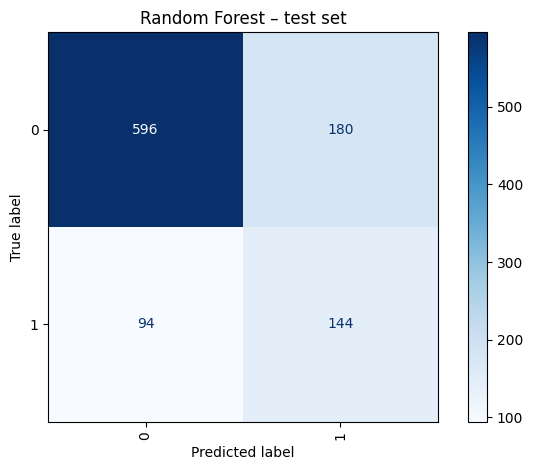

In [176]:
# confusion matrix using test set
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Random Forest – test set")
plt.tight_layout()
plt.show()

In [256]:
# auc
fpr, tpr, _ = roc_curve(y_test, y_test_prob[:, 1])
roc_auc = auc(fpr, tpr)
roc_auc

0.7565245170233041

In [ ]:
roc_curve()

## Use k-fold grid search 

In [212]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import make_scorer, recall_score, f1_score


# reload data
X_train_raw = pd.read_parquet("../data/model_raw/X_train.parquet")
y_train_raw = pd.read_parquet("../data/model_raw/Y_train.parquet")
y_train_raw = np.where(y_train_raw['depression_severity'] > 0, 1, 0) # create binary labels

# convert X and Y to np array
X_train = np.array(X_train_raw)
y_train = np.array(y_train_raw)


recall_minority = make_scorer(recall_score, pos_label=1)
f1_minority = make_scorer(f1_score, pos_label=1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

scoring = {
    'recall': recall_minority,
    'f1': f1_minority
}

pipeline = Pipeline([
    ('oversample', RandomOverSampler(random_state=7)),
    ('model', RandomForestClassifier(random_state=7))
])

grid = GridSearchCV(
    pipeline,
    param_grid={
        'model__n_estimators': [50, 100, 200, 300],
        'model__max_depth': [5, 8, 10, 12, 15],
        'model__min_samples_split':  [5, 10, 15, 20],
        'model__min_samples_leaf': [5, 10, 15, 20]
    },
    scoring=recall_minority,
    cv=skf,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=7))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 8, ...], 'model__min_samples_leaf': [5, 10, ...], 'model__min_samples_split': [5, 10, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(r..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosi

In [213]:
print("Best params:", grid.best_params_)
print("Best F1:", grid.best_score_)

Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 15, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best F1: 0.618120202515107


In [219]:
#  load train data
X_train_raw = pd.read_parquet("../data/model_raw/X_train.parquet")
y_train_raw = pd.read_parquet("../data/model_raw/Y_train.parquet")
y_train_raw = np.where(y_train_raw['depression_severity'] > 0, 1, 0) # create binary labels

# upsample train data - do what you need to do
ros = RandomOverSampler(sampling_strategy='not majority', random_state=7)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train_raw, y_train_raw)

# convert X and Y to np array
X_train = np.array(X_train_balanced)
y_train = np.array(y_train_balanced)


rf  = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1, 
    random_state=7, 
    max_depth=5, 
    max_features='log2', 
    min_samples_leaf = 15, 
    min_samples_split = 5)

rf.fit(X_train, y_train)

# save model
joblib.dump(rf, "nhanes_rf_kfold.pkl")

# load model from file
gb2 = joblib.load("nhanes_rf_kfold.pkl")

performance_metrics(gb2, X_train, y_train, X_val, y_val)



Train accuracy: 0.7694
Validation accuracy: 0.7456
Classification report: 
               precision    recall  f1-score   support

           0       0.86      0.78      0.82       739
           1       0.52      0.65      0.58       275

    accuracy                           0.75      1014
   macro avg       0.69      0.72      0.70      1014
weighted avg       0.77      0.75      0.75      1014



{'0': {'precision': 0.8573551263001485,
  'recall': 0.7807848443843031,
  'f1-score': 0.8172804532577904,
  'support': 739.0},
 '1': {'precision': 0.5249266862170088,
  'recall': 0.6509090909090909,
  'f1-score': 0.5811688311688312,
  'support': 275.0},
 'accuracy': 0.7455621301775148,
 'macro avg': {'precision': 0.6911409062585787,
  'recall': 0.715846967646697,
  'f1-score': 0.6992246422133108,
  'support': 1014.0},
 'weighted avg': {'precision': 0.7671994842657665,
  'recall': 0.7455621301775148,
  'f1-score': 0.7532462362218301,
  'support': 1014.0}}

In [220]:
# predict on test set

gb2 = joblib.load("nhanes_rf_kfold.pkl")
y_test_pred = gb2.predict(X_test)

classification_report(y_test, y_test_pred, output_dict=True)

{'0': {'precision': 0.8634361233480177,
  'recall': 0.7577319587628866,
  'f1-score': 0.8071379547014413,
  'support': 776.0},
 '1': {'precision': 0.43543543543543545,
  'recall': 0.6092436974789915,
  'f1-score': 0.5078809106830122,
  'support': 238.0},
 'accuracy': 0.722879684418146,
 'macro avg': {'precision': 0.6494357793917266,
  'recall': 0.6834878281209391,
  'f1-score': 0.6575094326922268,
  'support': 1014.0},
 'weighted avg': {'precision': 0.7629783681969382,
  'recall': 0.722879684418146,
  'f1-score': 0.7368981356911986,
  'support': 1014.0}}

In [221]:
# auc
fpr, tpr, _ = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)
roc_auc

0.6834878281209391

### Undersampled?

In [ ]:
# load train data
X_train_raw = pd.read_parquet("../data/model_raw/X_train.parquet")
y_train_raw = pd.read_parquet("../data/model_raw/Y_train.parquet")
y_train_raw = np.where(y_train_raw['depression_severity'] > 0, 1, 0) # create binary labels

ros = RandomUnderSampler(random_state=7)
X_train_under, y_train_under = ros.fit_resample(X_train_raw, y_train_raw)

# convert X and Y to np array
X_train_under = np.array(X_train_under)
y_train_under = np.array(y_train_under)

In [198]:
rf_under  = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1, 
    random_state=7, 
    max_depth=5, 
    max_features='log2', 
    min_samples_leaf = 5, 
    min_samples_split = 15)

rf_under.fit(X_train_under, y_train_under)

import joblib

# save model
joblib.dump(rf_under, "nhanes_rf_undersampled_1.pkl")

# load model from file
gb2 = joblib.load("nhanes_rf_undersampled_1.pkl")

performance_metrics(gb2, X_train_under, y_train_under, X_val, y_val)


Train accuracy: 0.7682
Validation accuracy: 0.7219
Classification report: 
               precision    recall  f1-score   support

           0       0.86      0.74      0.80       739
           1       0.49      0.66      0.56       275

    accuracy                           0.72      1014
   macro avg       0.67      0.70      0.68      1014
weighted avg       0.76      0.72      0.73      1014



{'0': {'precision': 0.8553654743390358,
  'recall': 0.7442489851150202,
  'f1-score': 0.7959479015918958,
  'support': 739.0},
 '1': {'precision': 0.49056603773584906,
  'recall': 0.6618181818181819,
  'f1-score': 0.5634674922600619,
  'support': 275.0},
 'accuracy': 0.7218934911242604,
 'macro avg': {'precision': 0.6729657560374425,
  'recall': 0.703033583466601,
  'f1-score': 0.6797076969259788,
  'support': 1014.0},
 'weighted avg': {'precision': 0.756430715891426,
  'recall': 0.7218934911242604,
  'f1-score': 0.7328984809151163,
  'support': 1014.0}}

In [199]:
# predict on test set

gb2 = joblib.load("nhanes_rf_undersampled_1.pkl")
y_test_pred = gb2.predict(X_test)

classification_report(y_test, y_test_pred, output_dict=True)

{'0': {'precision': 0.8635658914728682,
  'recall': 0.7177835051546392,
  'f1-score': 0.7839549612948628,
  'support': 776.0},
 '1': {'precision': 0.4065040650406504,
  'recall': 0.6302521008403361,
  'f1-score': 0.4942339373970346,
  'support': 238.0},
 'accuracy': 0.6972386587771203,
 'macro avg': {'precision': 0.6350349782567593,
  'recall': 0.6740178029974877,
  'f1-score': 0.6390944493459487,
  'support': 1014.0},
 'weighted avg': {'precision': 0.7562870801406514,
  'recall': 0.6972386587771203,
  'f1-score': 0.7159533797488242,
  'support': 1014.0}}

In [200]:
# auc
fpr, tpr, _ = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)
roc_auc

0.6740178029974877